# Neurônio Linear: Funções de Agregação e Ativação

**Resumo da pesquisa:** este notebook investiga como o neurônio linear agrega entradas por uma transformação afim e por que funções de ativação não-lineares são necessárias para quebrar a linearidade em redes neurais.

**Tese central:** empilhar camadas lineares não aumenta a expressividade do modelo. A profundidade passa a ser útil quando cada camada combina uma agregação linear com uma função de ativação não-linear.

**Roteiro**

1. Agregação linear: soma ponderada e viés  
2. Interpretação geométrica: hiperplanos e fronteiras de decisão  
3. Colapso da linearidade em redes profundas sem ativação  
4. Funções de ativação e suas derivadas  
5. XOR como contraexemplo clássico para modelos lineares  
6. Transformação do espaço de features com ativações  
7. Conclusões


In [ ]:
import os
import warnings
from pathlib import Path

os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"
warnings.filterwarnings("ignore")

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from sklearn.decomposition import PCA
from sklearn.datasets import make_moons
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import accuracy_score, mean_squared_error
from sklearn.neural_network import MLPClassifier, MLPRegressor
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

np.random.seed(42)

try:
    plt.style.use("seaborn-v0_8-whitegrid")
except OSError:
    pass

DPI = 120
FIG_DIR = Path(".")

plt.rcParams.update({
    "figure.dpi": DPI,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.titlesize": 11,
    "axes.labelsize": 10,
})


## 1. Agregação linear

Um neurônio artificial começa agregando as entradas em um escalar:

$$
z = \sum_{i=1}^{n} w_i x_i + b = \mathbf{w}^{\top}\mathbf{x} + b
$$

Nessa equação:

- $\mathbf{x}$ é o vetor de entrada;
- $\mathbf{w}$ é o vetor de pesos;
- $b$ é o viés, que desloca a fronteira;
- $z$ é o potencial de ativação antes da função $\varphi$.

Essa agregação é uma **transformação afim**. Ela pode rotacionar, escalar, inverter e deslocar o espaço, mas ainda preserva linearidade no sentido geométrico: as regiões de decisão continuam separadas por hiperplanos.


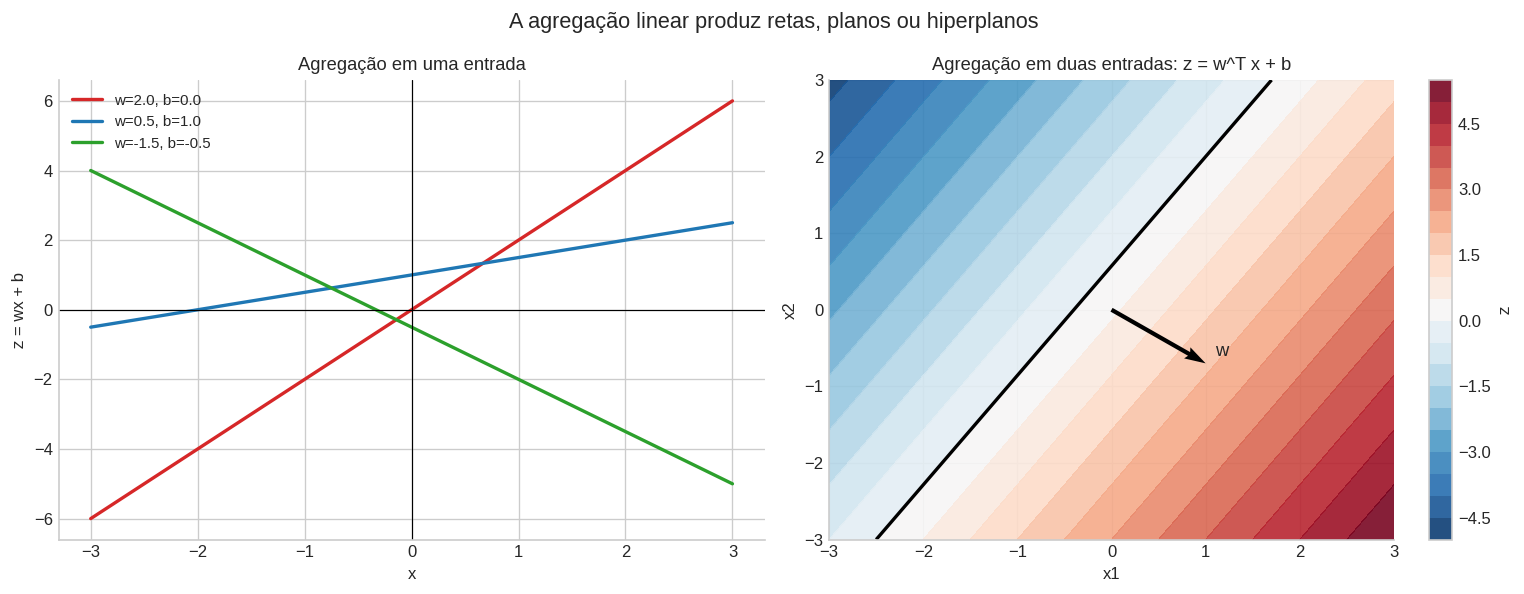

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

x_range = np.linspace(-3, 3, 300)
configs = [
    {"w": 2.0, "b": 0.0, "label": "w=2.0, b=0.0", "color": "#d62728"},
    {"w": 0.5, "b": 1.0, "label": "w=0.5, b=1.0", "color": "#1f77b4"},
    {"w": -1.5, "b": -0.5, "label": "w=-1.5, b=-0.5", "color": "#2ca02c"},
]

ax = axes[0]
for cfg in configs:
    z = cfg["w"] * x_range + cfg["b"]
    ax.plot(x_range, z, label=cfg["label"], color=cfg["color"], linewidth=2)
ax.axhline(0, color="black", linewidth=0.7)
ax.axvline(0, color="black", linewidth=0.7)
ax.set_xlabel("x")
ax.set_ylabel("z = wx + b")
ax.set_title("Agregação em uma entrada")
ax.legend(fontsize=9)

xx, yy = np.meshgrid(np.linspace(-3, 3, 160), np.linspace(-3, 3, 160))
w = np.array([1.0, -0.7])
b = 0.4
zz = w[0] * xx + w[1] * yy + b

ax = axes[1]
cf = ax.contourf(xx, yy, zz, levels=24, cmap="RdBu_r", alpha=0.9)
ax.contour(xx, yy, zz, levels=[0], colors="black", linewidths=2)
ax.quiver(0, 0, w[0], w[1], angles="xy", scale_units="xy", scale=1, color="black")
ax.text(w[0] + 0.1, w[1] + 0.1, "w", fontsize=11)
fig.colorbar(cf, ax=ax, label="z")
ax.set_xlabel("x1")
ax.set_ylabel("x2")
ax.set_title("Agregação em duas entradas: z = w^T x + b")

plt.suptitle("A agregação linear produz retas, planos ou hiperplanos", fontsize=13)
plt.tight_layout()
plt.savefig("1_agregacao_linear.png", dpi=DPI, bbox_inches="tight")
plt.show()


## 2. Função de ativação

Após a agregação, o neurônio aplica uma função de ativação:

$$
a = \varphi(z) = \varphi(\mathbf{w}^{\top}\mathbf{x} + b)
$$

Se $\varphi(z) = z$, o neurônio continua linear/afim. Se $\varphi$ é não-linear, cada neurônio passa a recortar ou deformar o espaço de entrada de uma forma que não pode ser reduzida a um único hiperplano.

Por isso, uma camada neural completa pode ser escrita como:

$$
\mathbf{h} = \varphi(W\mathbf{x} + \mathbf{b})
$$

O termo $W\mathbf{x}+\mathbf{b}$ agrega. A função $\varphi$ quebra a linearidade.


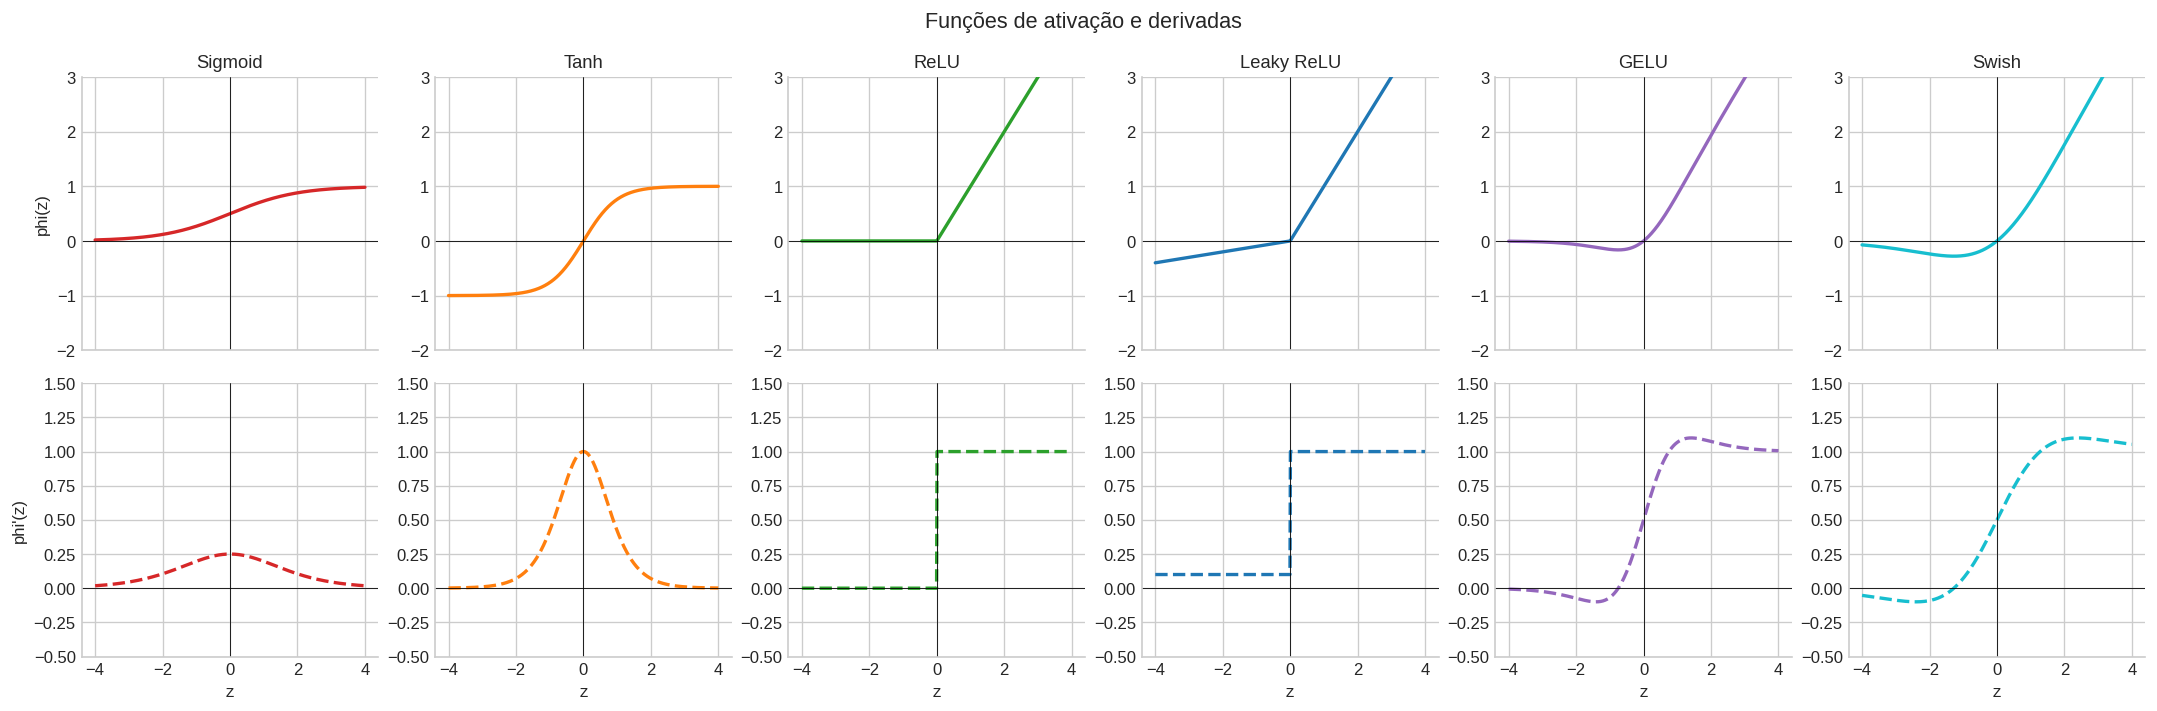

In [ ]:
def sigmoid(z):
    return 1 / (1 + np.exp(-z))


def sigmoid_d(z):
    s = sigmoid(z)
    return s * (1 - s)


def tanh_fn(z):
    return np.tanh(z)


def tanh_d(z):
    return 1 - np.tanh(z) ** 2


def relu(z):
    return np.maximum(0, z)


def relu_d(z):
    return (z > 0).astype(float)


def leaky_relu(z):
    return np.where(z > 0, z, 0.1 * z)


def leaky_relu_d(z):
    return np.where(z > 0, 1.0, 0.1)


def gelu(z):
    return z * sigmoid(1.702 * z)


def gelu_d(z):
    s = sigmoid(1.702 * z)
    return s + 1.702 * z * s * (1 - s)


def swish(z):
    return z * sigmoid(z)


def swish_d(z):
    s = sigmoid(z)
    return s + z * s * (1 - s)


activations = [
    ("Sigmoid", sigmoid, sigmoid_d, "#d62728"),
    ("Tanh", tanh_fn, tanh_d, "#ff7f0e"),
    ("ReLU", relu, relu_d, "#2ca02c"),
    ("Leaky ReLU", leaky_relu, leaky_relu_d, "#1f77b4"),
    ("GELU", gelu, gelu_d, "#9467bd"),
    ("Swish", swish, swish_d, "#17becf"),
]

z = np.linspace(-4, 4, 600)
fig, axes = plt.subplots(2, 6, figsize=(18, 6), sharex=True)

for i, (name, fn, dfn, color) in enumerate(activations):
    axes[0, i].plot(z, fn(z), color=color, linewidth=2)
    axes[0, i].axhline(0, color="black", linewidth=0.5)
    axes[0, i].axvline(0, color="black", linewidth=0.5)
    axes[0, i].set_title(name)
    axes[0, i].set_ylim(-2, 3)
    if i == 0:
        axes[0, i].set_ylabel("phi(z)")

    axes[1, i].plot(z, dfn(z), color=color, linewidth=2, linestyle="--")
    axes[1, i].axhline(0, color="black", linewidth=0.5)
    axes[1, i].axvline(0, color="black", linewidth=0.5)
    axes[1, i].set_ylim(-0.5, 1.5)
    axes[1, i].set_xlabel("z")
    if i == 0:
        axes[1, i].set_ylabel("phi'(z)")

plt.suptitle("Funções de ativação e derivadas", fontsize=13)
plt.tight_layout()
plt.savefig("2_ativacoes_derivadas.png", dpi=DPI, bbox_inches="tight")
plt.show()


### Papel das derivadas no treinamento

Durante o backpropagation, a derivada da ativação aparece pela regra da cadeia:

$$
\frac{\partial L}{\partial z}
=
\frac{\partial L}{\partial a}
\cdot
\varphi'(z)
$$

Assim, a ativação não serve apenas para representar funções não-lineares. Ela também controla como o erro flui para camadas anteriores. Sigmoid e tanh podem saturar quando $|z|$ é grande, reduzindo o gradiente. ReLU evita boa parte dessa saturação no semieixo positivo, mas zera o gradiente quando $z \le 0$.


## 3. Colapso da linearidade

Considere duas camadas sem ativação não-linear:

$$
\mathbf{h} = W_1\mathbf{x} + \mathbf{b}_1
$$

$$
\mathbf{y} = W_2\mathbf{h} + \mathbf{b}_2
$$

Substituindo $\mathbf{h}$:

$$
\mathbf{y}
= W_2(W_1\mathbf{x}+\mathbf{b}_1)+\mathbf{b}_2
= (W_2W_1)\mathbf{x} + (W_2\mathbf{b}_1+\mathbf{b}_2)
$$

Logo, duas camadas lineares equivalem a uma única camada linear. O mesmo vale para qualquer profundidade. Esse é o **colapso da linearidade**.


In [ ]:
rng = np.random.default_rng(42)

X = rng.normal(size=(6, 3))
W1 = rng.normal(size=(4, 3))
b1 = rng.normal(size=(4,))
W2 = rng.normal(size=(2, 4))
b2 = rng.normal(size=(2,))

deep_linear = (X @ W1.T + b1) @ W2.T + b2
collapsed_W = W2 @ W1
collapsed_b = W2 @ b1 + b2
single_linear = X @ collapsed_W.T + collapsed_b

print("Maior diferença absoluta entre a rede profunda linear e a camada equivalente:")
print(np.max(np.abs(deep_linear - single_linear)))


Maior diferença absoluta entre a rede profunda linear e a camada equivalente:
4.440892098500626e-16


A igualdade acima é algébrica. A próxima célula mostra o efeito prático: redes lineares de profundidades diferentes continuam incapazes de ajustar bem uma função não-linear como $\sin(x)$, enquanto uma rede com ReLU consegue aproximar a curvatura.


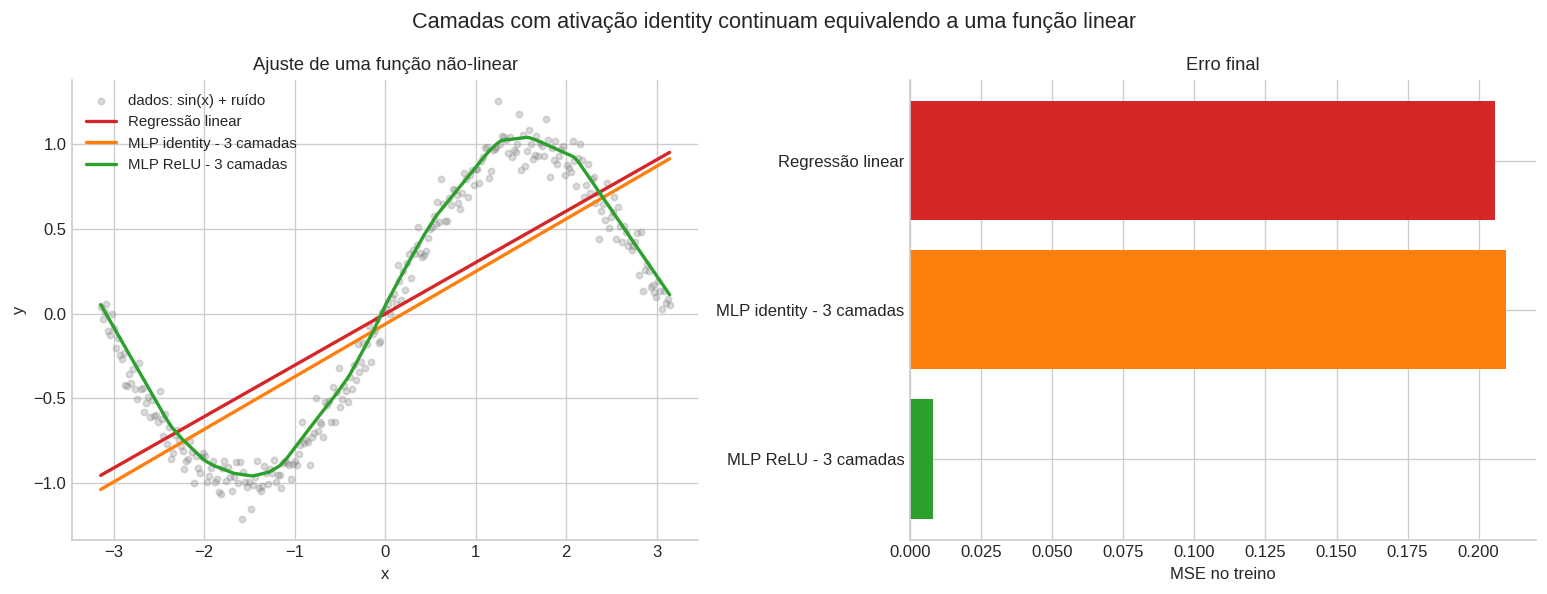

Modelo                       MSE final
------------------------------------------
Regressão linear             0.205857
MLP identity - 3 camadas     0.209686
MLP ReLU - 3 camadas         0.008176


In [ ]:
x_data = np.linspace(-np.pi, np.pi, 300)
y_data = np.sin(x_data) + 0.08 * np.random.randn(300)
X_train = x_data.reshape(-1, 1)
x_test = x_data.reshape(-1, 1)

model_configs = {
    "Regressão linear": LinearRegression(),
    "MLP identity - 3 camadas": make_pipeline(
        StandardScaler(),
        MLPRegressor(
            hidden_layer_sizes=(32, 32, 32),
            activation="identity",
            solver="adam",
            learning_rate_init=0.01,
            max_iter=2000,
            random_state=42,
        ),
    ),
    "MLP ReLU - 3 camadas": make_pipeline(
        StandardScaler(),
        MLPRegressor(
            hidden_layer_sizes=(32, 32, 32),
            activation="relu",
            solver="adam",
            learning_rate_init=0.01,
            max_iter=2000,
            random_state=42,
        ),
    ),
}
colors = ["#d62728", "#ff7f0e", "#2ca02c"]

predictions = {}
mses = {}
for name, model in model_configs.items():
    model.fit(X_train, y_data)
    predictions[name] = model.predict(x_test)
    mses[name] = mean_squared_error(y_data, model.predict(X_train))

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ax = axes[0]
ax.scatter(x_data, y_data, alpha=0.28, s=14, color="gray", label="dados: sin(x) + ruído")
for (name, y_pred), color in zip(predictions.items(), colors):
    ax.plot(x_test, y_pred, label=name, color=color, linewidth=2)
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_title("Ajuste de uma função não-linear")
ax.legend(fontsize=9)

ax = axes[1]
ax.barh(list(mses.keys()), list(mses.values()), color=colors)
ax.set_xlabel("MSE no treino")
ax.set_title("Erro final")
ax.invert_yaxis()

plt.suptitle("Camadas com ativação identity continuam equivalendo a uma função linear", fontsize=13)
plt.tight_layout()
plt.savefig("3_colapso_linearidade.png", dpi=DPI, bbox_inches="tight")
plt.show()

print(f"{'Modelo':28s} MSE final")
print("-" * 42)
for name, loss in mses.items():
    print(f"{name:28s} {loss:.6f}")


## 4. XOR: limite de uma fronteira linear

O problema XOR é um exemplo mínimo em que uma fronteira linear não basta:

| $x_1$ | $x_2$ | $y$ |
|:---:|:---:|:---:|
| 0 | 0 | 0 |
| 0 | 1 | 1 |
| 1 | 0 | 1 |
| 1 | 1 | 0 |

Os pontos da classe 1 ficam em cantos opostos do quadrado. Uma única reta não separa as classes. Uma rede com camada oculta e ativação não-linear cria regiões de decisão compostas.


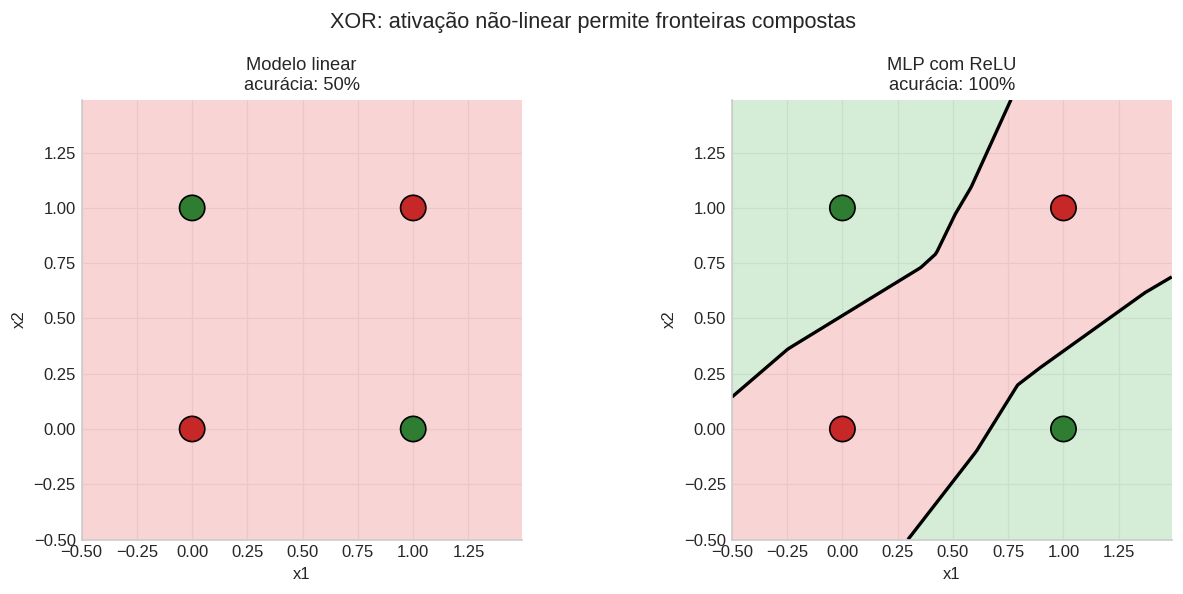

In [ ]:
def positive_score(model, X):
    if hasattr(model, "predict_proba"):
        return model.predict_proba(X)[:, 1]
    return model.predict(X)


def plot_decision_boundary(ax, model, X, y, title):
    step = 0.01
    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
    xx, yy = np.meshgrid(
        np.arange(x_min, x_max, step),
        np.arange(y_min, y_max, step),
    )
    grid = np.c_[xx.ravel(), yy.ravel()].astype(np.float32)
    Z = positive_score(model, grid).reshape(xx.shape)
    ax.contourf(
        xx,
        yy,
        Z,
        levels=[0, 0.5, 1],
        cmap=ListedColormap(["#f7c6c7", "#c8e6c9"]),
        alpha=0.75,
    )
    ax.contour(xx, yy, Z, levels=[0.5], colors="black", linewidths=2)
    ax.scatter(
        X[:, 0],
        X[:, 1],
        c=y.ravel(),
        cmap=ListedColormap(["#c62828", "#2e7d32"]),
        s=230,
        edgecolors="black",
        zorder=5,
    )
    acc = accuracy_score(y, model.predict(X))
    ax.set_title(f"{title}\nacurácia: {acc * 100:.0f}%")
    ax.set_xlabel("x1")
    ax.set_ylabel("x2")
    ax.set_aspect("equal", adjustable="box")


xor_X = np.array([[0, 0], [0, 1], [1, 0], [1, 1]], dtype=np.float32)
xor_y = np.array([0, 1, 1, 0], dtype=np.int64)

xor_linear = LogisticRegression().fit(xor_X, xor_y)
xor_mlp = MLPClassifier(
    hidden_layer_sizes=(8, 8),
    activation="relu",
    solver="lbfgs",
    max_iter=2000,
    random_state=42,
).fit(xor_X, xor_y)

fig, axes = plt.subplots(1, 2, figsize=(11, 5))
plot_decision_boundary(axes[0], xor_linear, xor_X, xor_y, "Modelo linear")
plot_decision_boundary(axes[1], xor_mlp, xor_X, xor_y, "MLP com ReLU")
plt.suptitle("XOR: ativação não-linear permite fronteiras compostas", fontsize=13)
plt.tight_layout()
plt.savefig("4_xor.png", dpi=DPI, bbox_inches="tight")
plt.show()


## 5. Transformação do espaço de features

Uma forma útil de interpretar redes neurais é separar duas etapas:

1. camadas ocultas aprendem uma representação $\mathbf{h}$;
2. a última camada separa essa representação.

Sem ativação, a representação oculta ainda é apenas uma transformação afim do espaço original. Com ReLU, a rede pode "dobrar" o espaço em regiões lineares por partes, tornando classes não-linearmente separáveis mais fáceis de separar. Para visualizar a camada oculta quando ela tem mais de duas unidades, projetamos a representação em 2D com PCA.


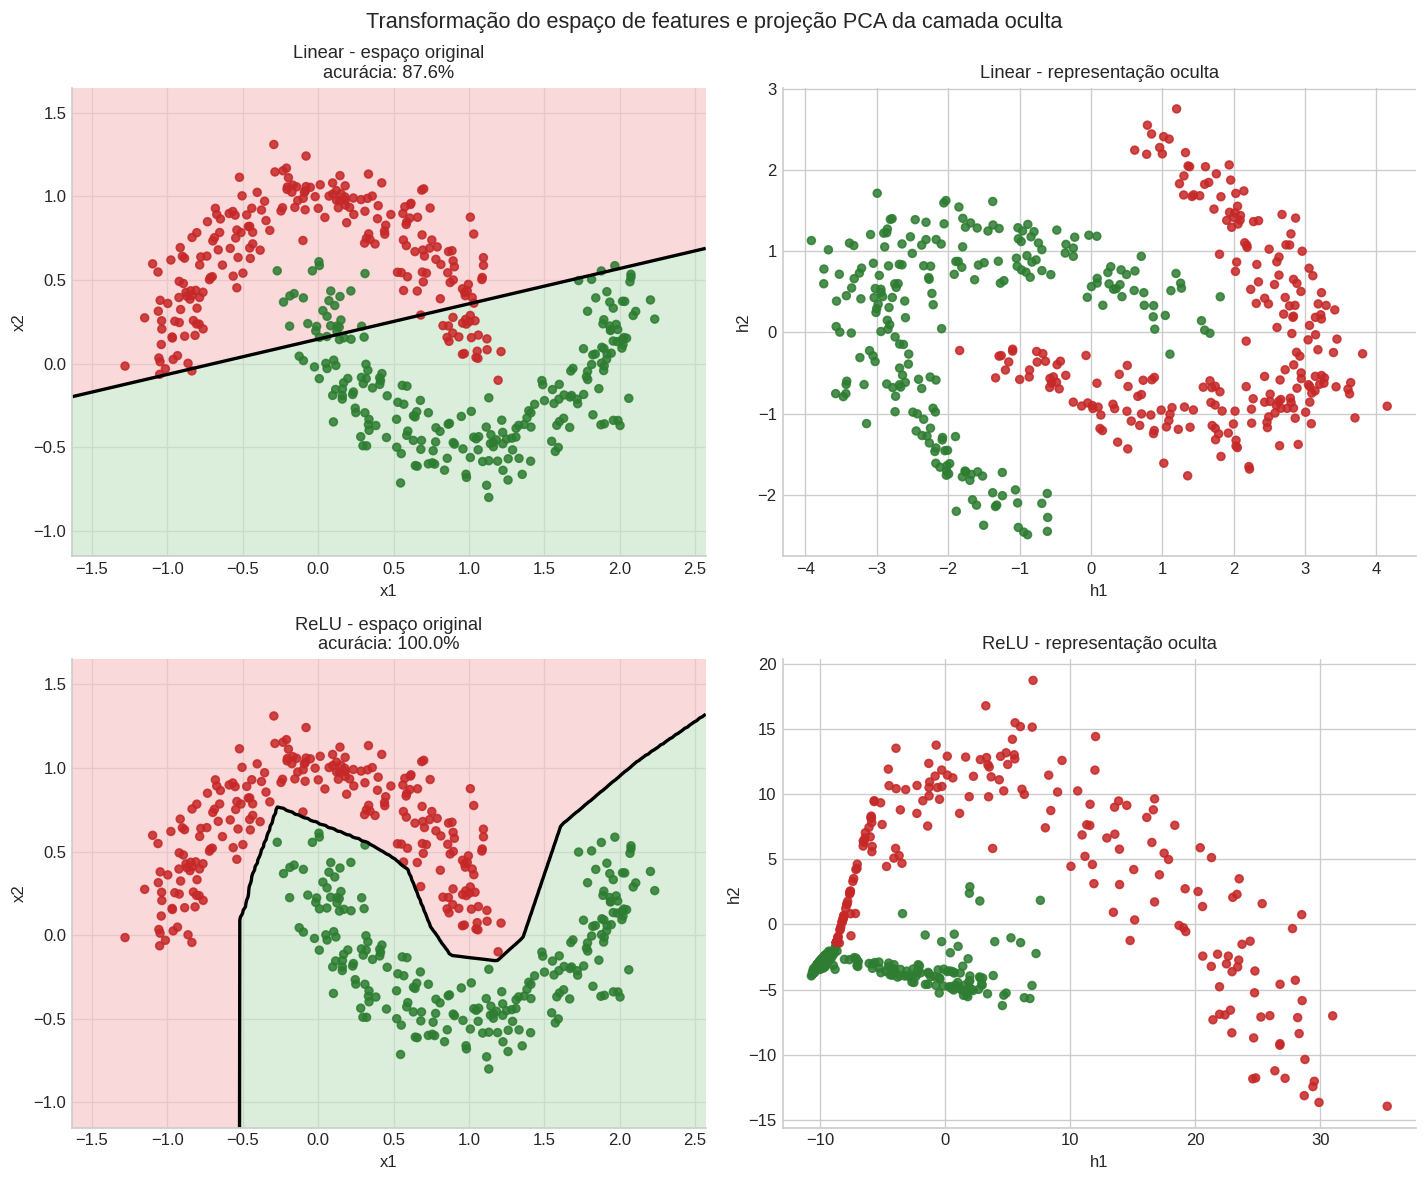

In [ ]:
X_moons, y_moons = make_moons(n_samples=450, noise=0.12, random_state=42)
X_moons = X_moons.astype(np.float32)

moon_linear = make_pipeline(
    StandardScaler(),
    MLPClassifier(
        hidden_layer_sizes=(8,),
        activation="identity",
        solver="lbfgs",
        max_iter=3000,
        random_state=42,
    ),
)
moon_linear.fit(X_moons, y_moons)

moon_relu = make_pipeline(
    StandardScaler(),
    MLPClassifier(
        hidden_layer_sizes=(8,),
        activation="relu",
        solver="lbfgs",
        max_iter=3000,
        random_state=42,
    ),
)
moon_relu.fit(X_moons, y_moons)


def hidden_representation(pipeline, X, activation):
    scaler = pipeline.named_steps["standardscaler"]
    mlp = pipeline.named_steps["mlpclassifier"]
    X_scaled = scaler.transform(X)
    H = X_scaled @ mlp.coefs_[0] + mlp.intercepts_[0]
    if activation == "relu":
        H = np.maximum(0, H)
    elif activation == "tanh":
        H = np.tanh(H)
    return H


h_linear = PCA(n_components=2, random_state=42).fit_transform(
    hidden_representation(moon_linear, X_moons, activation="identity")
)
h_relu = PCA(n_components=2, random_state=42).fit_transform(
    hidden_representation(moon_relu, X_moons, activation="relu")
)

cmap_points = ListedColormap(["#c62828", "#2e7d32"])


def plot_db_moons(ax, model, X, y, title):
    step = 0.02
    x_min, x_max = X[:, 0].min() - 0.35, X[:, 0].max() + 0.35
    y_min, y_max = X[:, 1].min() - 0.35, X[:, 1].max() + 0.35
    xx, yy = np.meshgrid(
        np.arange(x_min, x_max, step),
        np.arange(y_min, y_max, step),
    )
    grid = np.c_[xx.ravel(), yy.ravel()].astype(np.float32)
    Z = positive_score(model, grid).reshape(xx.shape)
    ax.contourf(
        xx,
        yy,
        Z,
        levels=[0, 0.5, 1],
        cmap=ListedColormap(["#f7c6c7", "#c8e6c9"]),
        alpha=0.65,
    )
    ax.contour(xx, yy, Z, levels=[0.5], colors="black", linewidths=2)
    ax.scatter(X[:, 0], X[:, 1], c=y, cmap=cmap_points, s=22, alpha=0.85)
    acc = accuracy_score(y, model.predict(X))
    ax.set_title(f"{title}\nacurácia: {acc * 100:.1f}%")
    ax.set_xlabel("x1")
    ax.set_ylabel("x2")


fig, axes = plt.subplots(2, 2, figsize=(12, 10))

plot_db_moons(axes[0, 0], moon_linear, X_moons, y_moons, "Linear - espaço original")
axes[0, 1].scatter(h_linear[:, 0], h_linear[:, 1], c=y_moons, cmap=cmap_points, s=22, alpha=0.85)
axes[0, 1].set_title("Linear - representação oculta")
axes[0, 1].set_xlabel("h1")
axes[0, 1].set_ylabel("h2")

plot_db_moons(axes[1, 0], moon_relu, X_moons, y_moons, "ReLU - espaço original")
axes[1, 1].scatter(h_relu[:, 0], h_relu[:, 1], c=y_moons, cmap=cmap_points, s=22, alpha=0.85)
axes[1, 1].set_title("ReLU - representação oculta")
axes[1, 1].set_xlabel("h1")
axes[1, 1].set_ylabel("h2")

plt.suptitle("Transformação do espaço de features e projeção PCA da camada oculta", fontsize=13)
plt.tight_layout()
plt.savefig("5_feature_space.png", dpi=DPI, bbox_inches="tight")
plt.show()


## 6. Síntese comparativa

| Aspecto | Rede apenas linear | Rede com ativação não-linear |
|:---|:---:|:---:|
| Operação principal | $W\mathbf{x}+\mathbf{b}$ | $\varphi(W\mathbf{x}+\mathbf{b})$ |
| Efeito da profundidade | Colapsa em uma camada | Aumenta composições não-lineares |
| Fronteira de decisão | Hiperplano | Regiões lineares por partes ou curvas |
| XOR | Não separa | Separa |
| Ajuste de funções curvas | Limitado | Flexível |
| Papel no gradiente | Derivada constante | Derivada controla saturação e fluxo |

**Conclusão:** a função de agregação define a combinação ponderada das evidências de entrada. A função de ativação decide se essa evidência continuará sendo uma transformação linear/afim ou se entrará em uma composição não-linear. Por isso, a ativação é o componente que impede o colapso da profundidade e permite que redes neurais aprendam relações como XOR, curvas e representações internas mais expressivas.


## 7.Referências principais

Este notebook foi construído a partir de duas referências de apoio:

- Khung, Gavin. *Perceptron*. GitHub: [gavinkhung/perceptron](https://github.com/gavinkhung/perceptron). Repositório usado como referência prática para implementação e visualização do perceptron.
- Géron, Aurélien. *Hands-On Machine Learning with Scikit-Learn, Keras, and TensorFlow*. O'Reilly Media. Livro usado como referência conceitual para redes neurais, funções de ativação, treinamento e aprendizado supervisionado.


## 8. Para saber mais


- Rosenblatt, F. (1958). *The Perceptron: A Probabilistic Model for Information Storage and Organization in the Brain*.
- Minsky, M. & Papert, S. (1969). *Perceptrons*.
- Cybenko, G. (1989). *Approximation by Superpositions of a Sigmoidal Function*.
- Goodfellow, I., Bengio, Y. & Courville, A. (2016). *Deep Learning*, capítulos 6 e 8.
